In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_percentage_error, r2_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import numpy as np

In [2]:
# 1. Load dataset
df = pd.read_csv("fixed_cleaned_crmls_dataset.txt")
df

,Unnamed: 0,ViewYN,PoolPrivateYN,ClosePrice,Latitude,Longitude,LivingArea,CountyOrParish,AttachedGarageYN,ParkingTotal,BathroomsTotalInteger,City,BedroomsTotal,FireplaceYN,LotSizeArea,NewConstructionYN,HighSchoolDistrict,PostalCode,BuildingAge,StoriesFinal
0,15,True,False,681877.0,33.725080,-117.222302,2824.0,Riverside,True,2.0,3.0,Menifee,5.0,False,7000.0,True,Mendocino Unified,92586,1.0,2.0
1,17,True,False,900000.0,34.203479,-118.643567,2500.0,Los Angeles,True,2.0,3.0,Los Angeles,5.0,True,8336.0,False,Call Listing Office,91307,54.0,2.0
2,19,False,False,862000.0,34.460368,-118.490755,2363.0,Los Angeles,True,2.0,3.0,Saugus,5.0,True,11705.0,False,William S. Hart Union,91390,30.0,2.0
3,20,False,False,5149000.0,34.043218,-118.519477,3338.0,Los Angeles,False,2.0,5.0,Pacific Palisades,4.0,True,6502.0,False,NaN,90272,21.0,2.0
4,25,False,False,1710000.0,37.669495,-121.763793,2485.0,Alameda,True,2.0,3.0,Livermore,4.0,True,5093.0,False,Livermore Valley,94550,14.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35772,125414,False,False,566990.0,33.700193,-117.371513,1435.0,Riverside,True,2.0,2.0,Lake Elsinore,3.0,False,6680.0,True,Lake Elsinore Unified,92530,1.0,1.0
35773,125420,True,False,495000.0,34.378787,-117.330930,2226.0,San Bernardino,True,2.0,3.0,Hesperia,4.0,True,18000.0,False,Hesperia Unified,92345,35.0,2.0
35774,125421,True,False,435000.0,34.854045,-119.148141,1753.0,Kern,True,2.0,3.0,Pine Mountain Club,3.0,True,10104.0,False,El Tejon Unified,93225,19.0,2.0
35775,125447,True,False,740000.0,33.891018,-118.087100,1186.0,Los Angeles,False,4.0,1.0,Norwalk,2.0,True,6211.0,False,Norwalk - La Mirada,90650,76.0,1.0


In [3]:
# 2. Separate features and target
y = df["ClosePrice"]
X = df.drop(columns=["ClosePrice","Unnamed: 0","HighSchoolDistrict","BuildingAge"])

In [4]:
# 3. Identify numeric and categorical features
numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(exclude=[np.number]).columns.tolist()

In [5]:
# 4. Handle missing values (replace with median/most frequent)
# This will be done inside the pipeline using SimpleImputer
from sklearn.impute import SimpleImputer
numeric_transformer = Pipeline(steps=[("imputer", SimpleImputer(strategy="median"))])
categorical_transformer = Pipeline(steps=[("imputer", SimpleImputer(strategy="most_frequent")),("onehot", OneHotEncoder(handle_unknown="ignore"))])


In [6]:
# 5. Combine preprocessing
preprocessor = ColumnTransformer(transformers=[("num", numeric_transformer, numeric_features),("cat", categorical_transformer, categorical_features)])

In [7]:
# 6. Define model
model = RandomForestRegressor(n_estimators=300,random_state=42,n_jobs=-1)

In [8]:
# 7. Build pipeline
pipeline = Pipeline(steps=[("preprocessor", preprocessor),("model", model)])

In [9]:
# 8. Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [10]:
# 9. Fit the model
pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['Latitude', 'Longitude',
                                                   'LivingArea', 'ParkingTotal',
                                                   'BathroomsTotalInteger',
                                                   'BedroomsTotal',
                                                   'LotSizeArea']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['ViewYN', 'PoolPrivateYN',
                                                   'CountyOrParish',
                                                   'AttachedGarageYN', 'City',
                                                   'FireplaceYN',
                                                   'NewConstructionYN',
                                                   'PostalCode',
                                                   'StoriesFinal'])])),
                ('model',
                 RandomForestRegressor(n_estimators=300, n_jobs=-1,
                                       random_state=42))])

In [11]:
# 10. Predictions
y_pred = pipeline.predict(X_test)

In [12]:
# Apply natural log to actual and predicted prices
y_test_log = np.log(y_test)
y_pred_log = np.log(y_pred)

In [13]:
# 11. Evaluate
print("Mean Absolute Percentage Error:", mean_absolute_percentage_error(y_test_log, y_pred_log))
print("R² Score:", r2_score(y_test_log, y_pred_log))


Mean Absolute Percentage Error: 0.008550979210495607
R² Score: 0.8611203450632293


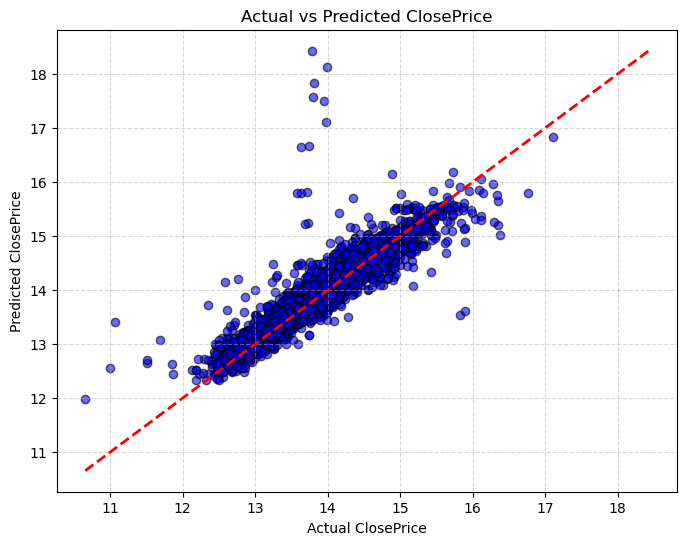

In [14]:
import matplotlib.pyplot as plt
# Actual vs Predicted values
plt.figure(figsize=(8, 6))
plt.scatter(y_test_log, y_pred_log, alpha=0.6, color='blue', edgecolor='k')

# Add reference line (perfect prediction)
max_val = max(max(y_test_log), max(y_pred_log))
min_val = min(min(y_test_log), min(y_pred_log))
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2)

plt.title('Actual vs Predicted ClosePrice')
plt.xlabel('Actual ClosePrice')
plt.ylabel('Predicted ClosePrice')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()
